# Land Cover Classification Framework

The workflow will cover how to retrieve LandSat Imagery to begin development of a landcover classifier. We will use the landcover classifier to examine changes over time.

## Case Application: Great Salt Lake

The Great Salt Lake (GSL) fluctuates both from natural seasonality, year-to-year climate anomolies, and anthropogentic water use (e.g., diversions, growth, development). In today's example, we will retrieve LandSat imagery and develop a land cover classifier to examine the changes in area of the GSL over time.

## Lets label our images so that we have something to train our ML model on!

Developing a machine learning image classification model involves several key steps. 
1. Representative samples from the imagery need to be manually labeled to create a training dataset (e.g., identifying pixels as water or non-water). 
2. Use the labeled data to train a model, such as a Random Forest classifier, which learns the relationship between pixel values and land cover classes. 
3. Evaluate the model using a separate test dataset to assess its accuracy and ensure it generalizes well to unseen data. 
4. Apply the trained model to new images to generate classified outputs, which can be further analyzed (e.g., calculating lake surface area over time)


In [1]:
from utils import labeler, model_funcs, plotting
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from joblib import dump
from joblib import load
import numpy as np
import rasterio
import os
import matplotlib.pyplot as plt


In [9]:
labels_df = labeler.labeling_session(
    image_folder="data/LandSat/GSL",
    n_samples=100,
    crop_size=100,
    patch_size=5,
    out_csv="data/LandSat/GSL/training_samples.csv"
)

#1 is true, 0 is false

Saved 25 pixels ✔
Saved 25 pixels.

Saved labels to data/LandSat/GSL/training_samples.csv


In [10]:
#open file in excel to view
labels =  pd.read_csv("data/LandSat/GSL/training_samples.csv")
labels.tail()

,blue,green,red,ndwi,brightness,label,source_file
2461,0.872638,0.860816,0.817404,0.025868,0.850286,0,GSL_1995_05.tif
2462,0.632477,0.566854,0.510031,0.052766,0.569787,0,GSL_1995_05.tif
2463,0.624299,0.548460,0.490003,0.056292,0.554254,0,GSL_1995_05.tif
2464,0.646647,0.573311,0.515323,0.053267,0.578427,0,GSL_1995_05.tif
2465,0.622599,0.553254,0.497474,0.053087,0.557776,0,GSL_1995_05.tif


## Now we can start the model training steps!

### Step 1. Train the model

In [11]:
# Load your labeled data
df = pd.read_csv("data/LandSat/GSL/training_samples.csv")

# Features (must match what you created earlier)
FEATURES = ["blue", "green", "red", "ndwi", "brightness"]

X = df[FEATURES].values
y = df["label"].values.astype(int)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

dump(model, "data/LandSat/GSL/water_rf_model.joblib")

['data/LandSat/GSL/water_rf_model.joblib']

### Step 2. Evaluate the model

What matters most for our GSl project
* High Recall (water) → you don’t miss lake pixels
* Moderate Precision → some false water is okay, but not too much
* Missing water (FN) is usually worse than slightly overestimating it (FP)


### Confusion Matrix
|                          | **Predicted Water (1)** | **Predicted Not Water (0)** |
| ------------------------ | ----------------------- | --------------------------- |
| **Actual Water (1)**     | True Positive (TP)      | False Negative (FN)         |
| **Actual Not Water (0)** | False Positive (FP)     | True Negative (TN)          |


### Terms
| Term   | Meaning                      | In the project                     |
| ------ | ---------------------------- | ----------------------------------- |
| **TP** | Correctly predicted positive | Water correctly identified as water |
| **TN** | Correctly predicted negative | Land correctly identified as land   |
| **FP** | Incorrect positive           | Land mistakenly classified as water |
| **FN** | Incorrect negative           | Water missed (classified as land)   |

### Metric fuctions

| Metric                | Formula                                         | Interpretation                         |
| --------------------- | ----------------------------------------------- | -------------------------------------- |
| **Accuracy**          | (TP + TN) / Total                               | Overall correctness                    |
| **Precision (Water)** | TP / (TP + FP)                                  | How reliable water predictions are     |
| **Recall (Water)**    | TP / (TP + FN)                                  | How much water you successfully detect |
| **F1 Score**          | 2 × (Precision × Recall) / (Precision + Recall) | Balance between precision and recall   |


In [12]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[461   7]
 [  6 143]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       468
           1       0.95      0.96      0.96       149

    accuracy                           0.98       617
   macro avg       0.97      0.97      0.97       617
weighted avg       0.98      0.98      0.98       617



## Happy with your model? Lets apply it!



In [13]:
model = load("data/LandSat/GSL/water_rf_model.joblib")
inpath = "data/LandSat/GSL"
outpath = "prediction/LandSat/GSL"
date = "2013_07"

input_filepath = f"{inpath}/GSL_{date}.tif"
output_filepath = f"{outpath}/GSL_{date}.tif"

#make the filepath directory if it doesn't exist
os.makedirs(outpath, exist_ok=True)

mask = model_funcs.classify_image(
    tif_path=input_filepath,
    model=model,
    out_path=output_filepath
)

## Lets see if you model is working well

Lake area: 3143.00 km²


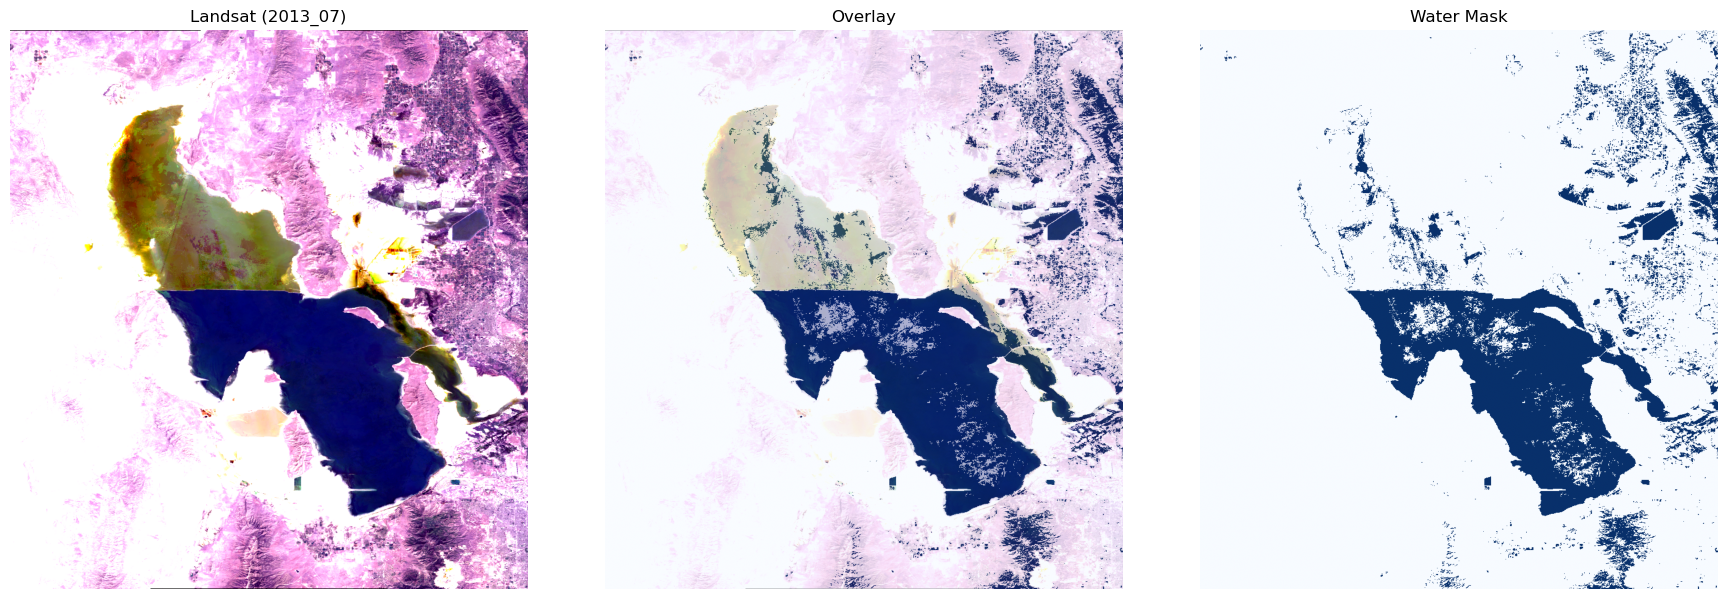

In [14]:
area = model_funcs.water_area_km2(mask, pixel_size_m=150)
print(f"Lake area: {area:.2f} km²")


plotting.plot_image_overlay_mask(input_filepath, mask, date=date)


# Exercise

Wow, our model needs substantial improvement! Your boss at NASA wants you to refine the Random Forest Image Classifier using two steps:
* Expand the number of samples in your training dataset
* Optimize the Hyperparameters using the GridSearchCV function

Demonstrate that the model performs well in an out of training sample image (as above) and apply the model to all images. 

Using the predictions, create a time-series plot of surface area changes over time. Hint, make a new dataframe with the timestamp of each image (column or index) and the predicted area. 

In [15]:
# apply model to all images in the folder
for filename in os.listdir(inpath):
    if filename.endswith(".tif"):
        date = filename.split("_")[1].split(".")[0]
        input_filepath = os.path.join(inpath, filename)
        output_filepath = os.path.join(outpath, filename)
        
        mask = model_funcs.classify_image(
            tif_path=input_filepath,
            model=model,
            out_path=output_filepath
        )
        
        area = model_funcs.water_area_km2(mask, pixel_size_m=150)
        print(f"{date}: Lake area: {area:.2f} km²")

1985: Lake area: 5590.60 km²
1985: Lake area: 5424.68 km²
1985: Lake area: 6446.09 km²
1985: Lake area: 6033.31 km²
1985: Lake area: 5714.12 km²
1985: Lake area: 5686.81 km²
1985: Lake area: 5506.34 km²
1985: Lake area: 4627.96 km²
1985: Lake area: 4746.49 km²
1985: Lake area: 4148.23 km²
1985: Lake area: 4304.02 km²
1985: Lake area: 5640.73 km²
1986: Lake area: 6096.96 km²
1986: Lake area: 6285.94 km²
1986: Lake area: 5316.28 km²
1986: Lake area: 4944.17 km²
1986: Lake area: 5396.04 km²
1986: Lake area: 5456.11 km²
1986: Lake area: 5563.98 km²
1986: Lake area: 5356.57 km²
1986: Lake area: 5551.83 km²
1986: Lake area: 6252.73 km²
1986: Lake area: 6157.66 km²
1986: Lake area: 6154.72 km²
1987: Lake area: 4923.18 km²
1987: Lake area: 6032.14 km²
1987: Lake area: 6070.64 km²
1987: Lake area: 5937.48 km²
1987: Lake area: 5167.40 km²
1987: Lake area: 5909.02 km²
1987: Lake area: 6035.67 km²
1987: Lake area: 6483.56 km²
1987: Lake area: 6456.49 km²
1987: Lake area: 6310.80 km²
1987: Lake are

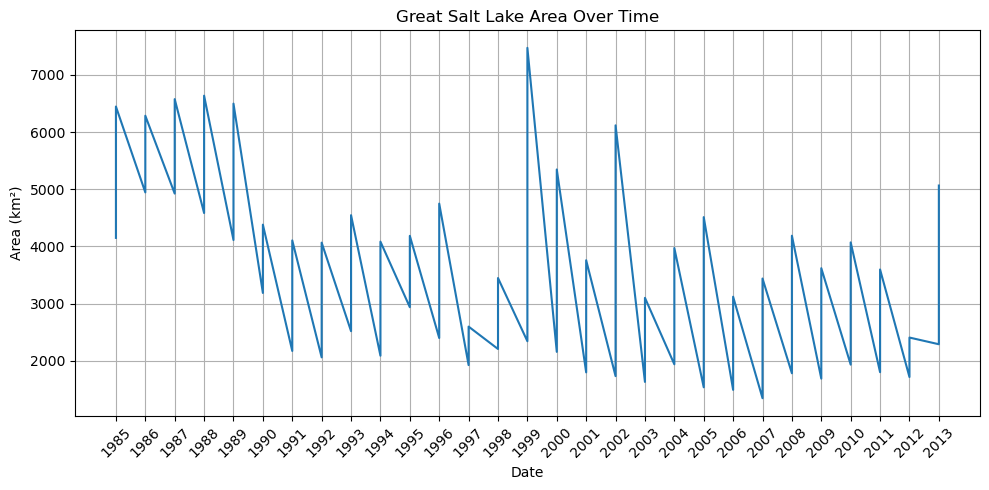

In [17]:
# plot lake area over time using the above results
dates = []
areas = []  
for filename in os.listdir(outpath):
    if filename.endswith(".tif"):
        date = filename.split("_")[1].split(".")[0]
        output_filepath = os.path.join(outpath, filename)
        
        with rasterio.open(output_filepath) as src:
            mask = src.read(1)
        
        area = model_funcs.water_area_km2(mask, pixel_size_m=150)
        dates.append(date)
        areas.append(area)  
# Sort by date
dates, areas = zip(*sorted(zip(dates, areas)))
plt.figure(figsize=(10, 5))
plt.plot(dates, areas, marker='')
plt.title("Great Salt Lake Area Over Time")
plt.xlabel("Date")
plt.ylabel("Area (km²)")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()